<img src="../assets/coffee_banner.jpg" align="left" width="30%" hspace="20">

<table border="0" cellspacing="0" cellpadding="0" rules="none"><tr><td align="left"><b>
  <font size="7" color="#6B3E26">C </font>
  <font size="7" color="#8B5A2B">O </font>
  <font size="7" color="#A47148">F </font>
  <font size="7" color="#A47148">F </font>
  <font size="7" color="#C08A5A">E </font>
  <font size="7" color="#C08A5A">E </font>
  &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
  <font size="7" color="#6B3E26">S </font>
  <font size="7" color="#8B5A2B">U </font>
  <font size="7" color="#A47148">R </font>
  <font size="7" color="#A47148">V </font>
  <font size="7" color="#C08A5A">E </font>
  <font size="7" color="#C08A5A">Y </font><br>
  <font size="7" color="#8539ff">D A T A &nbsp;&nbsp;A N A L Y S I S </font>
</b>
</td></tr></table>
<p>
<font size="4">
  ■ <font size="4" color="#ff2584">This section</font> takes a closer look at the survey data <br>and identifies <font size="4" color="#ff2584"><b>CONSUMER PROFILES</b></font> based on <b>habits</b>,<br><b>consumption intensity</b>, <b>spending behaviour</b> <br>and <b>taste preferences</b>, exploring each group through <br><i><b>descriptive analysis</b></i> and <i><b>visualizations</b></i> using <br><b>PYTHON, PANDAS,</b> and <b>Matplotlib</b><br><br>
</font>
<font size="3">
  <b>Dataset: </b> <a href="https://www.youtube.com/watch?v=U489K2t_Tgc" target="_blank">
  "Great American Taste Test" </a><br><b> Public Major Coffee Survey from James Hoffmann</b> <br><i>(58 questions- 4,042 participants)</i>
</font>
</p>
<table width="100%" bgcolor="#000000" align="center">
  <tr width="100%" bgcolor="#000000"><td width="100%" align="center" bgcolor="#000000">
  <center>
  <font size="4" color="#A247F3FF"><b>
  <br>
    Being <font color="#ce1e73">PROGRAMMER</font> and <font color="#ce1e73">COFFEE LOVER</font> like many other programmers,<br> I choose this project to combine my <font color="#ce1e73">PASSION for CODING</font> <br>with exploring coffee consumption habits through <font color="#ce1e73">DATA ANALYSIS</font> <br><br>
  </b></font>
  </center>
  </tr></td>
</table>

In [1]:
import sys, os
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

in_colab = "google.colab" in sys.modules
if in_colab:
  if not os.path.exists("/content/coffee_survey"):
    print("Project Directory does not exist. Cloning Repository")
    !git clone https://github.com/briella-codes/coffee_survey.git
  else:
    print("Project Directory already exist. Skipping clone")
  %cd /content/coffee_survey
  !ls
  ROOT_DIR = Path("/content/coffee_survey")
else:
  ROOT_DIR = Path().resolve().parents[0]


print("root dir:", ROOT_DIR)
sys.path.append(str(ROOT_DIR))
sys.path.append('/content/coffee_survey/src/')

#IMPORT CUSTOM MODULES/FUNCTIONS:
from src.utils import             (                                             # type: ignore                    
                                  show_df, summary,
                                  print_title, print_subtitle,
                                  print_text, print_observation,
                                  load_pickle,
                                  save_plot
                                  ) 
from src.analysis import          (                                             # type: ignore
                                  group_and_count,
                                  calculate_percentage_by_group
                                  )
from src.visualization import     (                                             # type: ignore
                                  graphic_pie_chart,
                                  graphic_horizontal_bar_chart,
                                  graphic_heatmap
                                  )

# SETTING DISPLAY :
pd.set_option('display.width', None)
pd.set_option('display.max_rows', None)
#pd.reset_option('display.max_rows')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.colheader_justify', 'left')

root dir: D:\PORTFOLIO\coffee_survey


In [2]:
#LOAD PICKLE FILE FROM survey analysis notebook
survey_df = load_pickle('data/pickles/coffee_survey_df_eda.pkl')
#survey_df.info()
#show_df(survey_df.head(60))

# **SOME INTERESTING CONSUMERS PROFILES:**

## PROFILE "HEAVY COFFEE CONSUMER":

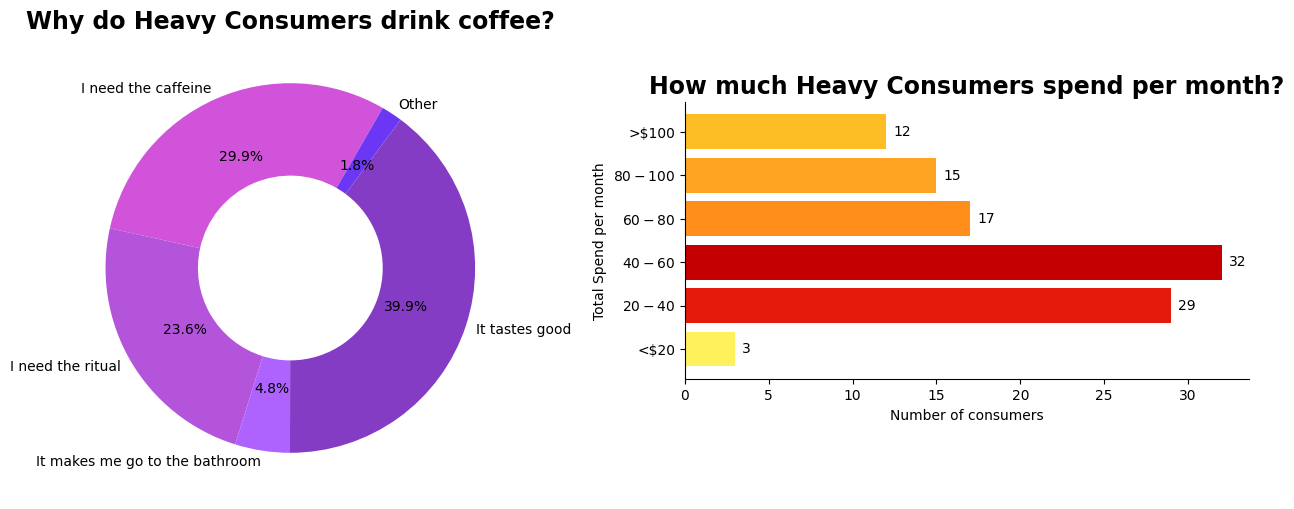

,additions,count,%
1,No - just black,90,75.0%
2,"Milk, dairy alternative, or coffee creamer",39,32.5%
3,Sugar or sweetener,13,10.8%
4,Flavor syrup,1,0.8%
5,Other,1,0.8%


*IMPORTANT NNOTES:  Record count doesn't include NA values 
 For this question multiple selection was allowed . Each percentage represents the real proportion of 
 consumers who selected each option , so the total sum of porcentages may exced 100%


In [3]:
#HEAVY CONSUMER: 4 OR MORE CUPS PER DAY, STRONG AND FULL CAFFEINED COFFEES
heavy_consumer_df = survey_df[(survey_df["cups"]>"3") & 
                                  (survey_df["strength"]>="Somewhat strong") &
                                  (survey_df["caffeine"]=="Full caffeine")
                                  ]
print_subtitle("Number of Heavy Coffee consumers: "+str(len(heavy_consumer_df))+ " (from "+str(len(survey_df))+")")
#show_df(heavy_consumer_df[["age","gender","roast_level","where_drink","additions","sweetener","wfh","total_spend","taste","why_drink","employment_status"]], head=20)

#también sería interesante analizar si son estudiantes o trabajadores-( pendiente)
heavy_consumer_why_drink = group_and_count(heavy_consumer_df,"why_drink")
heavy_consumer_total_spend = group_and_count(heavy_consumer_df,"total_spend")

fig, (ax1_heavy,ax2_heavy) = plt.subplots(1,2, figsize=(16,6))

title1_heavy = "Why do Heavy Consumers drink coffee?"
graphic_pie_chart(ax1_heavy,heavy_consumer_why_drink,title1_heavy,angle=60,shape="donut")

title2_heavy ="How much Heavy Consumers spend per month?"
ax2_xy_labels = ("Number of consumers","Total Spend per month")

graphic_horizontal_bar_chart(ax2_heavy,heavy_consumer_total_spend,title2_heavy,ax2_xy_labels)
save_plot(fig,'profile_heavy_consumer_charts_why_drink_how_much_spend.png')
plt.show()

heavy_consumer_additions_pct = calculate_percentage_by_group(heavy_consumer_df,"additions", sort="desc")
summary(heavy_consumer_additions_pct, show="display")

print("*IMPORTANT NNOTES: ",heavy_consumer_additions_pct.attrs['note_count'],"\n", heavy_consumer_additions_pct.attrs['note_multiple_sel'])

## PROFILE "PREMIUM SPENDER":

,age,gender,cups,where_drink,purchase,favorite,most_paid,most_willing,value_cafe,spent_equipment,value_equipment,employment_status,household_income,expertise
64,25-34 years old,Male,2,"('At home', 'At a cafe', 'On the go', 'At the office')",('Specialty coffee shop'),Cappuccino,More than $20,More than $20,No,"More than $1,000",Yes,Employed full-time,"$150,000 or more",8
75,25-34 years old,Male,2,"('At home', 'At a cafe', 'On the go')","('Specialty coffee shop', 'Drive-thru', 'Local cafe', 'National chain (e.g. Starbucks / Dunkin)')",Pourover,$10-$15,$10-$15,No,$500-$1000,Yes,Employed full-time,"$100,000 - $149,999",7
80,35-44 years old,Male,2,('At home'),<NA>,Espresso,$15-$20,More than $20,Yes,"More than $1,000",Yes,Employed full-time,"$150,000 or more",9
90,25-34 years old,Male,3,('At home'),<NA>,Latte,$15-$20,More than $20,Yes,$500-$1000,Yes,Employed full-time,"$75,000 - $99,999",3
94,35-44 years old,Male,3,('At home'),<NA>,Pourover,$10-$15,$10-$15,Yes,"More than $1,000",Yes,Employed full-time,"$75,000 - $99,999",8
101,25-34 years old,Male,2,('At home'),<NA>,Pourover,More than $20,More than $20,No,"More than $1,000",Yes,Employed full-time,"$75,000 - $99,999",7
104,18-24 years old,Male,2,"('At home', 'At the office', 'At a cafe')",<NA>,Latte,$10-$15,$10-$15,No,$300-$500,Yes,Employed full-time,"$100,000 - $149,999",7
108,25-34 years old,Male,1,"('At a cafe', 'At home')",<NA>,Iced coffee,$15-$20,More than $20,Yes,"More than $1,000",Yes,Student,"$50,000 - $74,999",8
110,25-34 years old,Male,2,"('At home', 'At a cafe')",<NA>,Espresso,$15-$20,$15-$20,Yes,"More than $1,000",Yes,Employed full-time,"$150,000 or more",8
114,25-34 years old,Male,2,('At home'),<NA>,Espresso,$10-$15,More than $20,Yes,"More than $1,000",Yes,Employed full-time,"$100,000 - $149,999",7


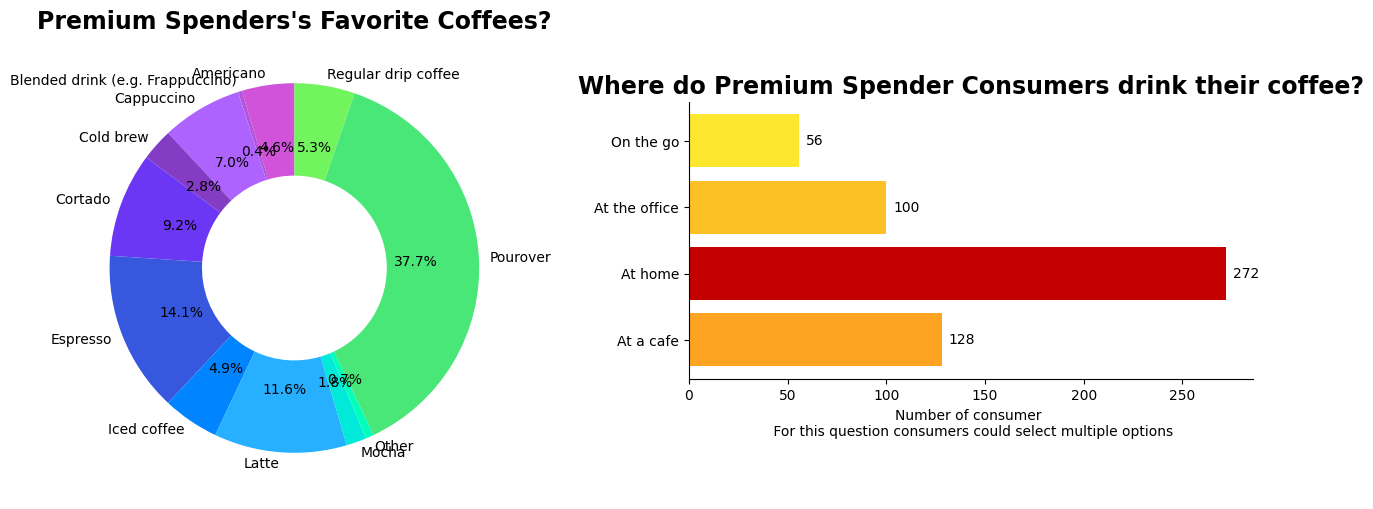

,Value for Money?,count,%
1,No,92,32.5%
2,Yes,191,67.5%


In [4]:
#PREMIUM SPENDER: WILLING TO SPEND and High total spend per month
premium_spender_df = survey_df[
                                (survey_df["most_willing"]>="$10-$15") &
                                (survey_df["most_paid"]>"$8-$10")&
                                (survey_df["total_spend"]>="$60-$80")
                                #(survey_df_eda["total_spend"]>="$80-$100")
                            ]

print_subtitle("Number of Coffee Premium Spenders: "+str(len(premium_spender_df))+ " (from "+str(len(survey_df))+")")

show_df(premium_spender_df[["age","gender","cups","where_drink","purchase","favorite","most_paid","most_willing","value_cafe","spent_equipment","value_equipment","employment_status","household_income","expertise"]], head=20)

fig, (ax1_spender,ax2_spender) = plt.subplots(1,2, figsize=(16,6))
spender_favorite = group_and_count(premium_spender_df,"favorite")
spender_where_drink = group_and_count(premium_spender_df,"where_drink")

title1_spender="Premium Spenders's Favorite Coffees?"
graphic_pie_chart(ax1_spender,spender_favorite,title1_spender,angle=90,shape="donut")

title2_spender ="Where do Premium Spender Consumers drink their coffee?"
graphic_horizontal_bar_chart(ax2_spender,spender_where_drink,title2_spender,("Number of consumer \n For this question consumers could select multiple options",""))

save_plot(fig,'profile_spender_consumer_charts_favorite_coffee_where_drink.png')
plt.show()

print_subtitle("Do Coffee Premium Spenders feel they get good value for money at a Café?")
premium_spender_value_cafe = calculate_percentage_by_group(premium_spender_df,"value_cafe",group_title="Value for Money?")
summary(premium_spender_value_cafe, show="display")

## PROFILE "COFFEE EXPERT":

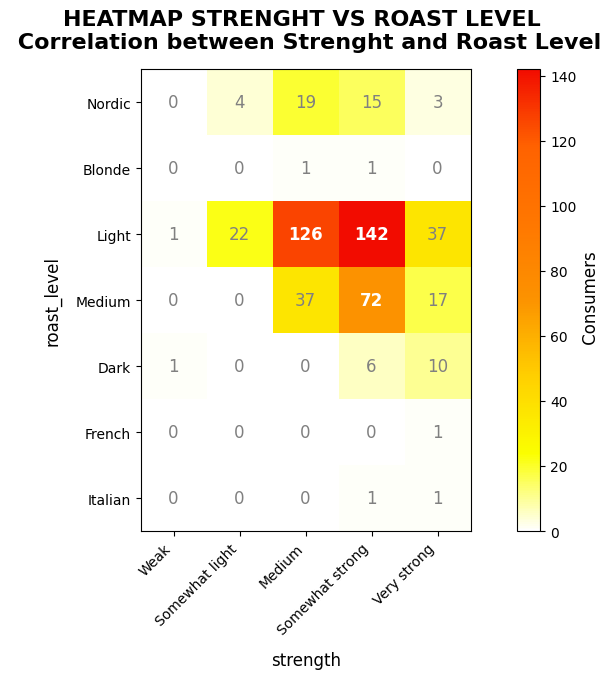

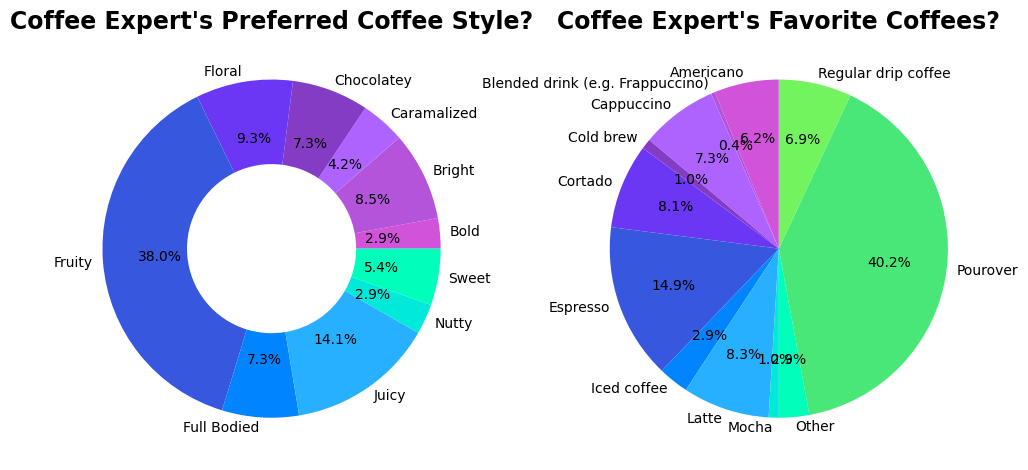

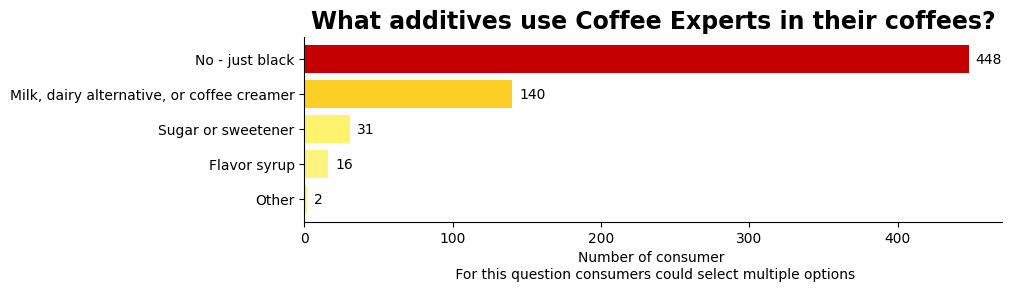

,Value for Money?,count,%
1,No,210,41.1%
2,Yes,301,58.9%


In [5]:
#COFFEE EXPERT: hight expertise level, know coffe source and answered about brewing
coffee_expert_df = survey_df[
                                (survey_df["expertise"]>=8) &
                                (survey_df["know_source"]=="Yes") &
                                (survey_df["brew"].notna())
                            ]

print_subtitle("Number of Coffee Experts: "+str(len(coffee_expert_df))+ " (from "+str(len(survey_df))+")")
#show_df(coffee_expert_df[["age","gender","where_drink","brew","favorite","style","strength","roast_level","additions","dairy","sweetener","spent_equipment"]], head=20)

#HEATMAP STRENGHT VS ROAST LEVEL
fig_hm, ax_strength_roast = plt.subplots(figsize=(12,6))
graphic_heatmap(ax_strength_roast,coffee_expert_df,'roast_level','strength',title="HEATMAP STRENGHT VS ROAST LEVEL \n Correlation between Strenght and Roast Level")

fig, (ax1_expert,ax2_expert) = plt.subplots(1,2, figsize=(12,12))
fig2, ax3_expert= plt.subplots(figsize=(9,4))

expert_style = group_and_count(coffee_expert_df,"style")
expert_favorite = group_and_count(coffee_expert_df,"favorite")
expert_additions = group_and_count(coffee_expert_df,"additions").sort_values(ascending=True)

title1_expert="Coffee Expert's Preferred Coffee Style?"
graphic_pie_chart(ax1_expert, expert_style, title1_expert, angle=0,shape="donut")
title2_expert="Coffee Expert's Favorite Coffees?"
graphic_pie_chart(ax2_expert, expert_favorite, title2_expert, angle=90,shape="pie")
save_plot(fig,'profile_coffee_expert_heatmap_strenght_vs_roast_level.png')

title3_expert="What additives use Coffee Experts in their coffees?"
graphic_horizontal_bar_chart(ax3_expert,expert_additions,title3_expert,("Number of consumer \n For this question consumers could select multiple options",""))
save_plot(fig2,'profile_coffee_expert_additives_bar_chart.png')

plt.show()

print_title("Do Coffee Experts feel they get good value for money at a café?")
expert_value_cafe = calculate_percentage_by_group(coffee_expert_df,"value_cafe",group_title="Value for Money?")
summary(expert_value_cafe, show="display")

## PROFILE "CAFE GOER":

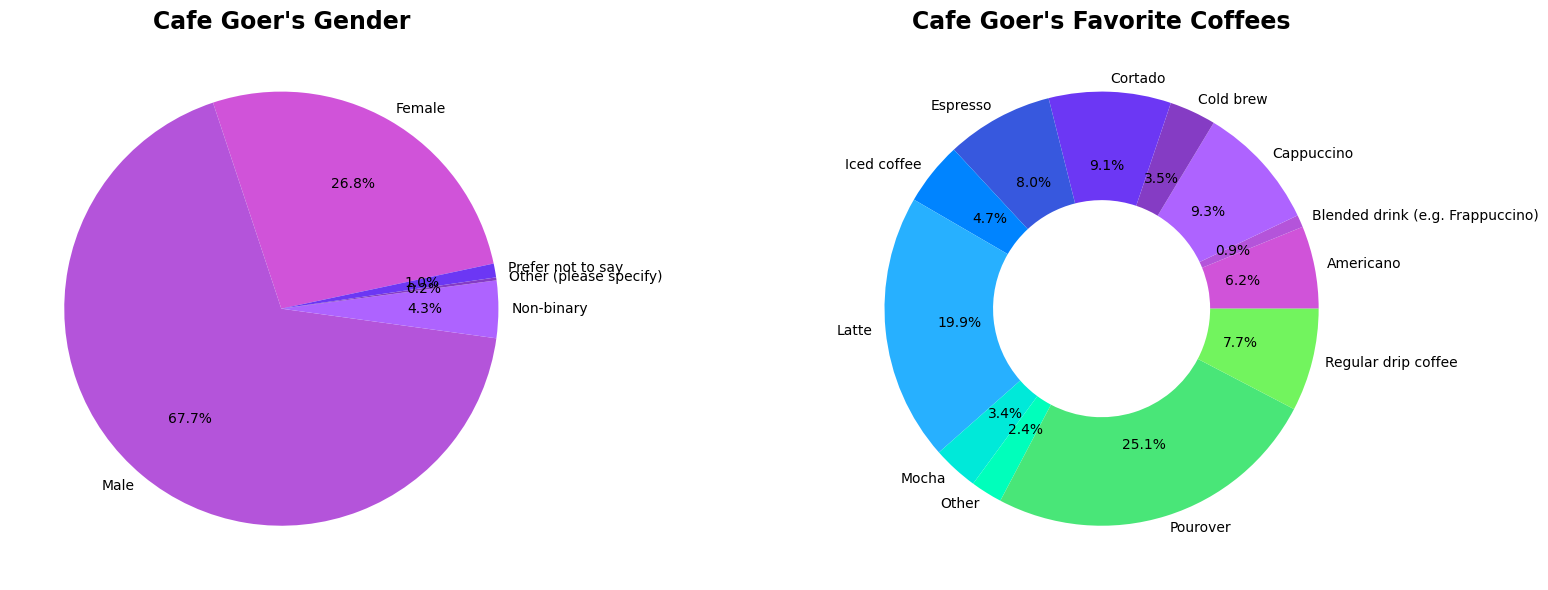

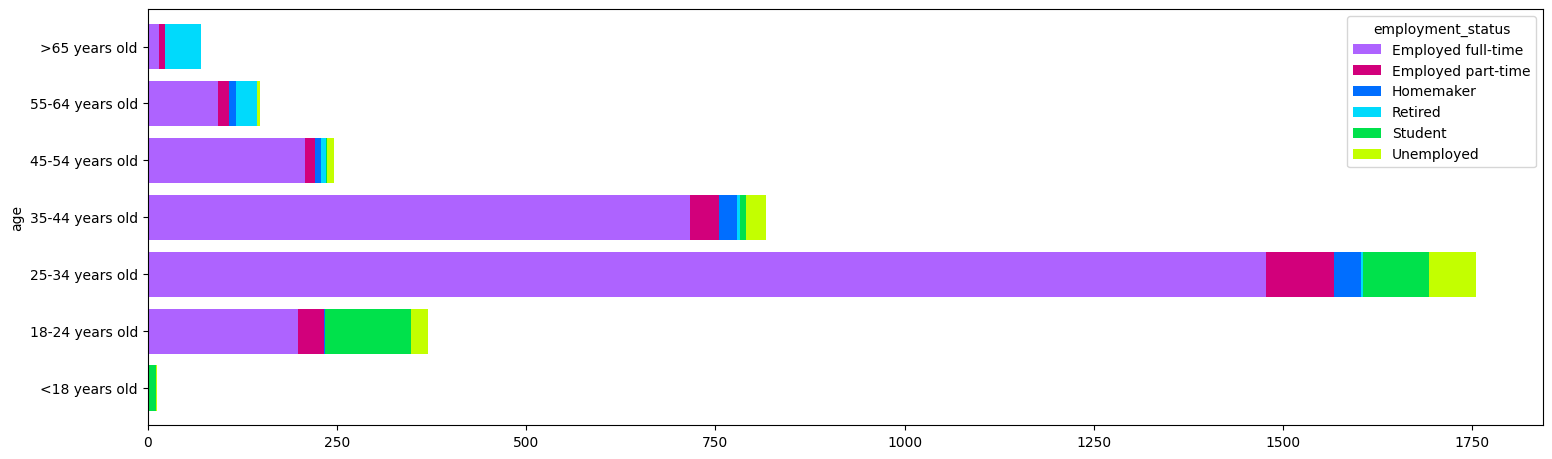

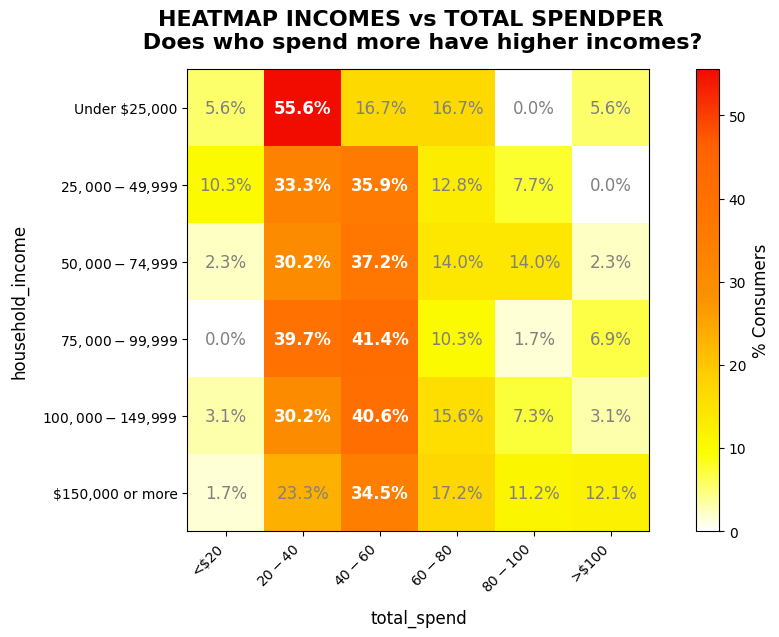

In [6]:
#CAFE GOER - Consumers who spend outside the home (at a cafe OR on the go)
cafe_goer_df = survey_df[( survey_df["where_drink"].notna())]
cafe_goer_df = cafe_goer_df[( cafe_goer_df["where_drink"].apply(lambda x: "At a cafe" in x)) |
                            ( cafe_goer_df["where_drink"].apply(lambda x: "On the go" in x)) ]

cafe_goer_gender = group_and_count(cafe_goer_df,"gender")
cafe_goer_fav = group_and_count(cafe_goer_df,"favorite")

print_subtitle("Number of Cafe Goers: "+str(len(cafe_goer_df))+ " (from "+str(len(survey_df))+")")
#show_df(cafe_goer_df[["age","gender","cups","purchase","favorite","total_spend","why_drink","most_paid","most_willing","value_cafe"]], head=20)

fig, (ax1_cafe_goer,ax2_cafe_goer) = plt.subplots(1,2,figsize=(18,6))
title1_cafe_goer="Cafe Goer's Gender"
graphic_pie_chart(ax1_cafe_goer, cafe_goer_gender, title1_cafe_goer, angle=12,shape="pie")
title2_cafe_goer="Cafe Goer's Favorite Coffees"
graphic_pie_chart(ax2_cafe_goer, cafe_goer_fav, title2_cafe_goer, angle=0,shape="donut")
plt.tight_layout()

fig2, ax3_cafe_goer = plt.subplots(figsize=(18,6))

#STACKED BAR CHART CAFE GOERS AGE EMPLOYMENT STATUS 
employment_status_by_age = survey_df.groupby(['age','employment_status'], observed=True).size()
employment_status_by_age = employment_status_by_age.unstack()

employment_status_by_age.plot(kind="barh", stacked=True, ax=ax3_cafe_goer,width=0.8,  color=["#ae63ff","#d2007b","#006eff","#00dafc","#00e14b", "#C3FF00"] )
pos = ax3_cafe_goer.get_position() 
ax3_cafe_goer.set_position([pos.x0, pos.y0+0.2, pos.width, pos.height * 0.9])
plt.show()

#HEATMAP HOUSEHOLD INCOME VS TOTAL_SPEND
fig_hm, ax_income_spend = plt.subplots(figsize=(12,6))
graphic_heatmap(ax_income_spend,coffee_expert_df,'household_income','total_spend',title="HEATMAP INCOMES vs TOTAL SPENDPER  \n Does who spend more have higher incomes?",percentage=True)
save_plot(fig_hm,'profile_cafe_goer_heatmap_income_vs_total_spend.png')

plt.show()